# 🚀 Fase 4: Análisis Exploratorio del NASA C-MAPSS (RUL)

El dataset C-MAPSS (Commercial Modular Aero-Propulsion System Simulation) de la NASA es el benchmark estándar en la industria para predecir la **Vida Útil Remanente (Remaining Useful Life - RUL)**.

A diferencia del dataset AI4I (que era una foto en el tiempo), este dataset contiene **series temporales multivariadas**. Cada motor ('unit_nr') arranca sano y se va degradando ciclo a ciclo hasta que falla. Nuestro objetivo es predecir cuántos ciclos le quedan.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('dark_background')
sns.set_palette("viridis")

## 1. Carga de Datos
El dataset original no tiene cabeceras. Contiene: `unit_nr`, `time_cycles`, 3 configuraciones operativas, y 21 sensores.

In [2]:
columns = ['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3'] + [f'sensor_{i}' for i in range(1, 22)]

train_df = pd.read_csv('../data/cmapss/train_FD001.txt', sep='\s+', header=None, names=columns)
test_df = pd.read_csv('../data/cmapss/test_FD001.txt', sep='\s+', header=None, names=columns)
truth_df = pd.read_csv('../data/cmapss/RUL_FD001.txt', sep='\s+', header=None, names=['RUL'])

print(f"Dimensiones de entrenamiento: {train_df.shape}")
print(f"Cantidad de motores únicos en entrenamiento: {train_df['unit_nr'].nunique()}")
train_df.head()

Dimensiones de entrenamiento: (20631, 26)
Cantidad de motores únicos en entrenamiento: 100


,unit_nr,time_cycles,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 2. Creación del Target (RUL)
En los datos de entrenamiento, la máquina funciona hasta fallar (run-to-failure). 
Por lo tanto, el RUL real de un ciclo dado es simplemente el ciclo máximo de ese motor menos el ciclo actual.
Además, usaremos un modelo *Piecewise Linear*, limitando el RUL máximo a 125 ciclos, ya que es muy difícil predecir una falla cuando el motor está recién salido de fábrica (sano).

In [3]:
# Calculamos el ciclo máximo de cada motor
max_cycles = train_df.groupby('unit_nr')['time_cycles'].max().reset_index()
max_cycles.rename(columns={'time_cycles': 'max_cycle'}, inplace=True)

# Unimos y calculamos RUL
train_df = train_df.merge(max_cycles, on=['unit_nr'], how='left')
train_df['RUL'] = train_df['max_cycle'] - train_df['time_cycles']
train_df.drop('max_cycle', axis=1, inplace=True)

# Piecewise RUL (Clip en 125)
MAX_RUL = 125
train_df['RUL_clipped'] = train_df['RUL'].clip(upper=MAX_RUL)

train_df[['unit_nr', 'time_cycles', 'RUL', 'RUL_clipped']].head(10)

,unit_nr,time_cycles,RUL,RUL_clipped
0,1,1,191,125
1,1,2,190,125
2,1,3,189,125
3,1,4,188,125
4,1,5,187,125
5,1,6,186,125
6,1,7,185,125
7,1,8,184,125
8,1,9,183,125
9,1,10,182,125


## 3. Visualizando la Degradación
Veamos cómo un sensor clave (por ejemplo el Sensor 14) evoluciona a medida que el motor se acerca al fallo (RUL = 0).

In [4]:
def plot_sensor_degradation(sensor_name, engine_id=1):
    engine_data = train_df[train_df['unit_nr'] == engine_id]
    
    fig, ax1 = plt.subplots(figsize=(10, 5))
    
    ax1.plot(engine_data['time_cycles'], engine_data[sensor_name], 'c-')
    ax1.set_xlabel('Ciclos (Tiempo)')
    ax1.set_ylabel(f'Valor de {sensor_name}', color='c')
    
    ax2 = ax1.twinx()
    ax2.plot(engine_data['time_cycles'], engine_data['RUL_clipped'], 'y--')
    ax2.set_ylabel('RUL (Ciclos Restantes)', color='y')
    
    plt.title(f'Degradación de Motor {engine_id}: {sensor_name} vs RUL')
    plt.show()

# Probamos con el Sensor 14 (velocidad del rotor)
plot_sensor_degradation('sensor_14')

<Figure size 1000x500 with 2 Axes>

## 4. Selección de Features (Sensores con Tendencia)
Algunos sensores no varían o cambian en condiciones distintas a la degradación. Filtramos los que tengan mayor correlación con el RUL.

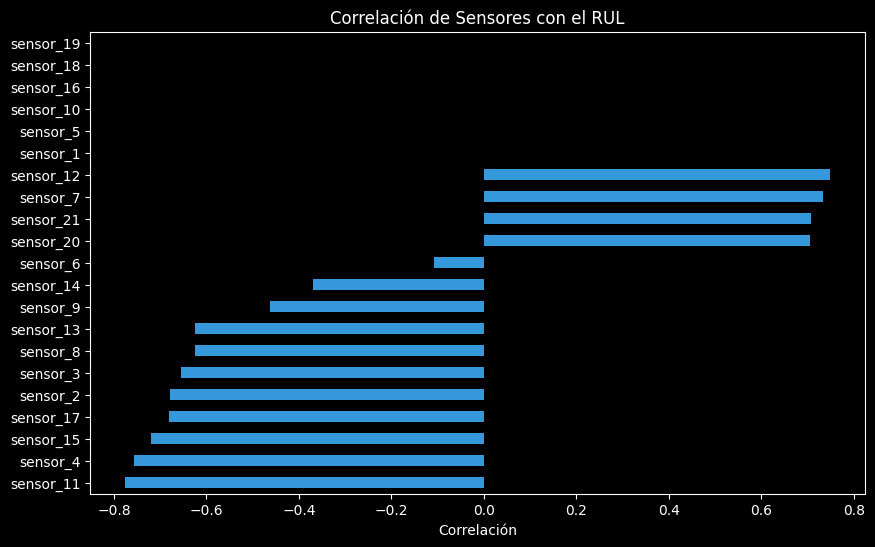


Sensores seleccionados (12): ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [5]:
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
correlations = train_df[sensor_cols + ['RUL_clipped']].corr()['RUL_clipped'].drop('RUL_clipped')

plt.figure(figsize=(10, 6))
correlations.sort_values().plot(kind='barh', color='#3498db')
plt.title('Correlación de Sensores con el RUL')
plt.xlabel('Correlación')
plt.show()

# Nos quedaremos con los sensores cuya correlación absoluta sea mayor a 0.5
useful_sensors = correlations[abs(correlations) > 0.5].index.tolist()
print(f"\nSensores seleccionados ({len(useful_sensors)}): {useful_sensors}")

## Conclusión del EDA C-MAPSS
1. Convertimos el dataset en un problema supervisado creando la variable `RUL_clipped`.
2. Eliminamos sensores planos (ruido constante) y nos quedamos con 14 sensores que muestran una clara tendencia monotónica de degradación.
3. En el próximo notebook armaremos secuencias temporales para alimentar nuestra red neuronal **LSTM**.

In [6]:
# Guardamos los sensores útiles en un archivo temporal para usarlos en el siguiente notebook
import joblib
joblib.dump(useful_sensors, '../models/useful_sensors_cmapss.pkl')
print("Features seleccionadas exportadas a models/useful_sensors_cmapss.pkl")

Features seleccionadas exportadas a models/useful_sensors_cmapss.pkl
